# Task 4.2

**4.2 predict magnitude of antibody response - H3N2 A/Massachusetts/18/2022 (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI / Measure: Single strain titer / Metric: Spearman correlation
* Full description: HAI titer for H3N2 A/Massachusetts/18/2022 at Day 28

> **Note — missing strain:** `H3N2 A/Massachusetts/18/2022` has no training measurements (challenge-only strain). Target is a proxy: mean of all available H3N2 d28 log2 titers per participant.

---

**y-values:** log2-transformed proxy (mean of H3N2 d28 log2 titers). CSVs use `np.exp2` to output raw titer scale values.

**Spearman correlation:** ranks predictions and truth; rewards monotonic agreement. Score: 1.0 = perfect, 0.0 = no signal.

**5-fold cross-validation:** each participant's prediction is made by a model that never saw them during training.

In [1]:
import os

import joblib
import numpy as np
import pandas as pd

from model_utils import evaluate, predict_challenge

In [2]:
USE_GOOGLE_COLAB = False

if USE_GOOGLE_COLAB:
    from google.colab import drive

    drive.mount('/content/drive')
    DATA_PATH = os.path.join(os.getcwd(), 'drive', 'MyDrive', 'DSE_260A', 'data', 'cleaned_data')
else:
    DATA_PATH = '../cleaned_data'

MODEL_PATH = 'models/task_4_2_model.pkl'
SUBMISSION_PATH = 'submission/task_4_2.csv'

In [3]:
train_participants = pd.read_csv(DATA_PATH + '/participants_cleaned.csv')
train_hai = pd.read_csv(DATA_PATH + '/hai_cleaned.csv')

# Data is pre-cleaned: one row per participant, HAI columns as HAI_{strain}_d{timepoint},
# participant columns as PART_{field}.
data = train_hai.merge(train_participants, on='participant_id', how='inner')
part_cols = [c for c in data.columns if c.startswith('PART_')]
print(f'Merged shape: {data.shape}')

# Challenge set: unseen participants we generate final submission predictions for.
challenge_participants = pd.read_csv(DATA_PATH + '/challenge_participants_cleaned.csv')
challenge_hai = pd.read_csv(DATA_PATH + '/challenge_hai_cleaned.csv')
challenge_data = challenge_hai.merge(challenge_participants, on='participant_id', how='inner')
print(f'Challenge shape: {challenge_data.shape}')

Merged shape: (3757, 199)
Challenge shape: (40, 21)


---

## Task 4.2 — H3N2 proxy HAI at Day 28

Proxy built from 25 H3N2 d28 strains
Samples: 3646   Features: 29
Spearman (5-fold CV): 0.626  (p-value: 0)
Model                                        RMSE        MSE      MAE   Spearman
Linear Regression (5-Fold CV)              1.6119     2.5982   1.2546     0.6259


C:\Users\User\AppData\Local\Temp\ipykernel_18748\4126574007.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[TARGET_COL] = data[h3n2_d28_cols].mean(axis=1)


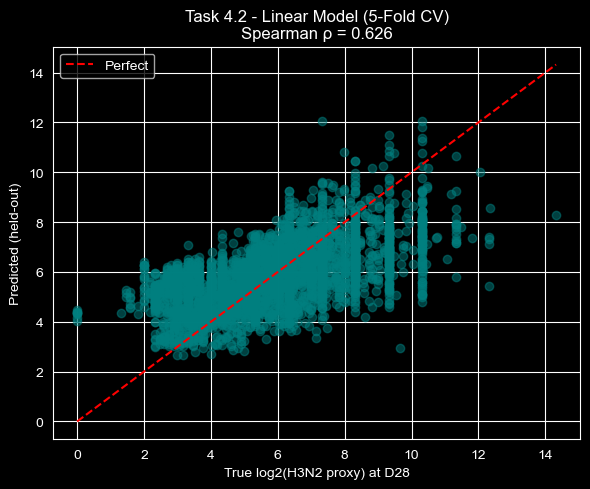

Model saved to models/task_4_2_model.pkl


In [4]:
# Proxy target: mean of all H3N2 d28 log2 titers (Massachusetts strain absent from training).
h3n2_d28_cols = [c for c in data.columns if 'H3N2' in c and c.endswith('_d28')]
h3n2_d0_cols = [c for c in data.columns if 'H3N2' in c and c.endswith('_d0')]
TARGET_COL = 'H3N2_proxy_d28'
data[TARGET_COL] = data[h3n2_d28_cols].mean(axis=1)
feature_cols = h3n2_d0_cols + part_cols
print(f'Proxy built from {len(h3n2_d28_cols)} H3N2 d28 strains')

y_vals = data[TARGET_COL].copy()
mask = y_vals.notna()
y_vals = y_vals[mask]
X = data.loc[mask, feature_cols].copy()

y_pred_cv, model = evaluate(X, y_vals, 'Task 4.2', y_axis_label='True log2(H3N2 proxy) at D28')

os.makedirs('models', exist_ok=True)
joblib.dump(model, MODEL_PATH)
print(f'Model saved to {MODEL_PATH}')

In [5]:
y_pred_challenge = predict_challenge(model, challenge_data, feature_cols)

results = pd.DataFrame({
    'Participant_ID': challenge_data['participant_id'].values,
    'Task_4.2': np.exp2(y_pred_challenge),  # reverse log2 -> raw titer
})
os.makedirs('submission', exist_ok=True)
results.to_csv(SUBMISSION_PATH, index=False)
results

,Participant_ID,Task_4.2
0,2024_UGA.ID_077,76.568101
1,2024_UGA.ID_086,22.023497
2,2024_UGA.ID_128,405.496048
3,2024_UGA.ID_170,103.159883
4,2024_UGA.ID_179,46.549061
5,2024_UGA.ID_215,374.459505
6,2024_UGA.ID_219,44.734713
7,2024_UGA.ID_275,33.342611
8,2024_UGA.ID_295,30.624336
9,2024_UGA.ID_296,22.416691
